In [1]:
# ============================================================
# BLOQUE 1 — CARGA UNIVERSAL DEL EXPERIMENTO
# ============================================================

import os
import sys
import glob
import yaml
import joblib

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

# ============================================================
# DETECCIÓN ROBUSTA DEL ROOT DEL PROYECTO
# ============================================================

current = Path.cwd()

while current.name != "eeg_hmm_project":

    if current.parent == current:
        raise RuntimeError(
            "❌ No se encontró la carpeta eeg_hmm_project"
        )

    current = current.parent

project_root = str(current)

print("=" * 60)
print("PROJECT ROOT")
print("=" * 60)
print(project_root)

# ------------------------------------------------------------
# YAML
# ------------------------------------------------------------

YAML_NAME = "feat_task_k3_diag_hjorth.yaml"

yaml_path = os.path.join(
    project_root,
    "configs",
    "experiments",
    "depured_methology_experiments",
    YAML_NAME
)

print("\nYAML:")
print(yaml_path)

with open(yaml_path, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

exp_name = cfg['experiment']['name']

n_states = cfg['pipeline']['hmm']['k_states']

cov_type = cfg['pipeline']['hmm']['covariance_type']

print("\n" + "=" * 60)
print("EXPERIMENT CONFIG")
print("=" * 60)

print(f"Experiment: {exp_name}")
print(f"K States : {n_states}")
print(f"Cov Type : {cov_type}")

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def clean_path(path_str):

    limpio = (
        path_str
        .replace('../../', '')
        .replace('../', '')
    )

    return os.path.normpath(
        os.path.join(project_root, limpio)
    )

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

features_dir = clean_path(
    cfg['paths']['features_dir']
)

output_dir = clean_path(
    cfg['paths']['output_dir']
)

exp_dir = os.path.join(
    output_dir,
    exp_name
)

print("\n" + "=" * 60)
print("PATHS")
print("=" * 60)

print(f"Features Dir:\n{features_dir}")
print(f"\nExperiment Dir:\n{exp_dir}")

# ------------------------------------------------------------
# LOAD FEATURES
# ------------------------------------------------------------

feature_files = sorted(
    glob.glob(
        os.path.join(features_dir, '*_features.npy')
    )
)

print(f"\nFeatures files encontrados: {len(feature_files)}")

X_original = np.vstack([
    np.load(f)
    for f in feature_files
])

print(f"\nX_original shape: {X_original.shape}")

# ------------------------------------------------------------
# LOAD PCA MATRICES
# ------------------------------------------------------------

X_pca = np.load(
    os.path.join(exp_dir, 'X_pca.npy')
)

print(f"X_pca shape: {X_pca.shape}")

# ------------------------------------------------------------
# LOAD VITERBI
# ------------------------------------------------------------

viterbi_paths = np.load(
    os.path.join(
        exp_dir,
        f'viterbi_paths_k{n_states}.npy'
    )
)

print(f"Viterbi shape: {viterbi_paths.shape}")

# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------

model = joblib.load(
    os.path.join(
        exp_dir,
        f'hmm_model_k{n_states}.pkl'
    )
)

print("\n✅ Modelo cargado correctamente")

# ------------------------------------------------------------
# LOAD SCALER
# ------------------------------------------------------------

scaler = joblib.load(
    os.path.join(exp_dir, 'scaler.pkl')
)

X_scaled = scaler.transform(X_original)

print(f"\nX_scaled shape: {X_scaled.shape}")

# ------------------------------------------------------------
# SANITY CHECK
# ------------------------------------------------------------

assert len(viterbi_paths) == X_scaled.shape[0]

print("\n✅ Sanity check superado")

PROJECT ROOT
c:\Proyectos\eeg_hmm_project

YAML:
c:\Proyectos\eeg_hmm_project\configs\experiments\depured_methology_experiments\feat_task_k3_diag_hjorth.yaml

EXPERIMENT CONFIG
Experiment: feat_task_k3_diag_hjorth.yaml
K States : 3
Cov Type : diag

PATHS
Features Dir:
c:\Proyectos\eeg_hmm_project\data\interim\features\task_hjorthonly_temporalqc

Experiment Dir:
c:\Proyectos\eeg_hmm_project\outputs\processed\experiments\feature_hmm\task\feat_task_k3_diag_hjorth.yaml

Features files encontrados: 118

X_original shape: (25949, 38)
X_pca shape: (25949, 22)
Viterbi shape: (25949,)

✅ Modelo cargado correctamente

X_scaled shape: (25949, 38)

✅ Sanity check superado


In [2]:
# ============================================================
# BLOQUE 2 — DISTRIBUCIÓN GLOBAL
# ============================================================

print("=" * 60)
print(f"Distribución Global de Hidden States (K={n_states})")
print("=" * 60)

total_windows = len(viterbi_paths)

print(f"Total de ventanas: {total_windows:,}\n")

for s in range(n_states):

    count = np.sum(viterbi_paths == s)

    frac = count / total_windows

    print(
        f"State {s}: "
        f"{frac:.2%} "
        f"(n={count:,})"
    )

Distribución Global de Hidden States (K=3)
Total de ventanas: 25,949

State 0: 40.92% (n=10,618)
State 1: 35.16% (n=9,123)
State 2: 23.92% (n=6,208)


In [3]:
# ============================================================
# BLOQUE 3 — TRANSITION MATRIX
# ============================================================

transmat = model.transmat_

df_trans = pd.DataFrame(
    np.round(transmat, 3),
    columns=[f"To S{i}" for i in range(n_states)],
    index=[f"From S{i}" for i in range(n_states)]
)

print("=" * 60)
print("TRANSITION MATRIX")
print("=" * 60)

display(df_trans)

# ------------------------------------------------------------
# SELF TRANSITIONS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STATE PERSISTENCE")
print("=" * 60)

for s in range(n_states):

    occupancy = np.mean(viterbi_paths == s)

    persistence = transmat[s, s]

    count = np.sum(viterbi_paths == s)

    print(f"\nState {s}")
    print("-" * 20)

    print(f"Fractional Occupancy : {occupancy:.4f}")
    print(f"Total Windows        : {count:,}")
    print(f"Self-transition      : {persistence:.4f}")

TRANSITION MATRIX


,To S0,To S1,To S2
From S0,0.881,0.053,0.066
From S1,0.032,0.920,0.048
From S2,0.094,0.052,0.855



STATE PERSISTENCE

State 0
--------------------
Fractional Occupancy : 0.4092
Total Windows        : 10,618
Self-transition      : 0.8812

State 1
--------------------
Fractional Occupancy : 0.3516
Total Windows        : 9,123
Self-transition      : 0.9199

State 2
--------------------
Fractional Occupancy : 0.2392
Total Windows        : 6,208
Self-transition      : 0.8546


['Mobility', 'Complexity']
(3, 38)


C:\Users\pokem\AppData\Local\Temp\ipykernel_24260\2134628683.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


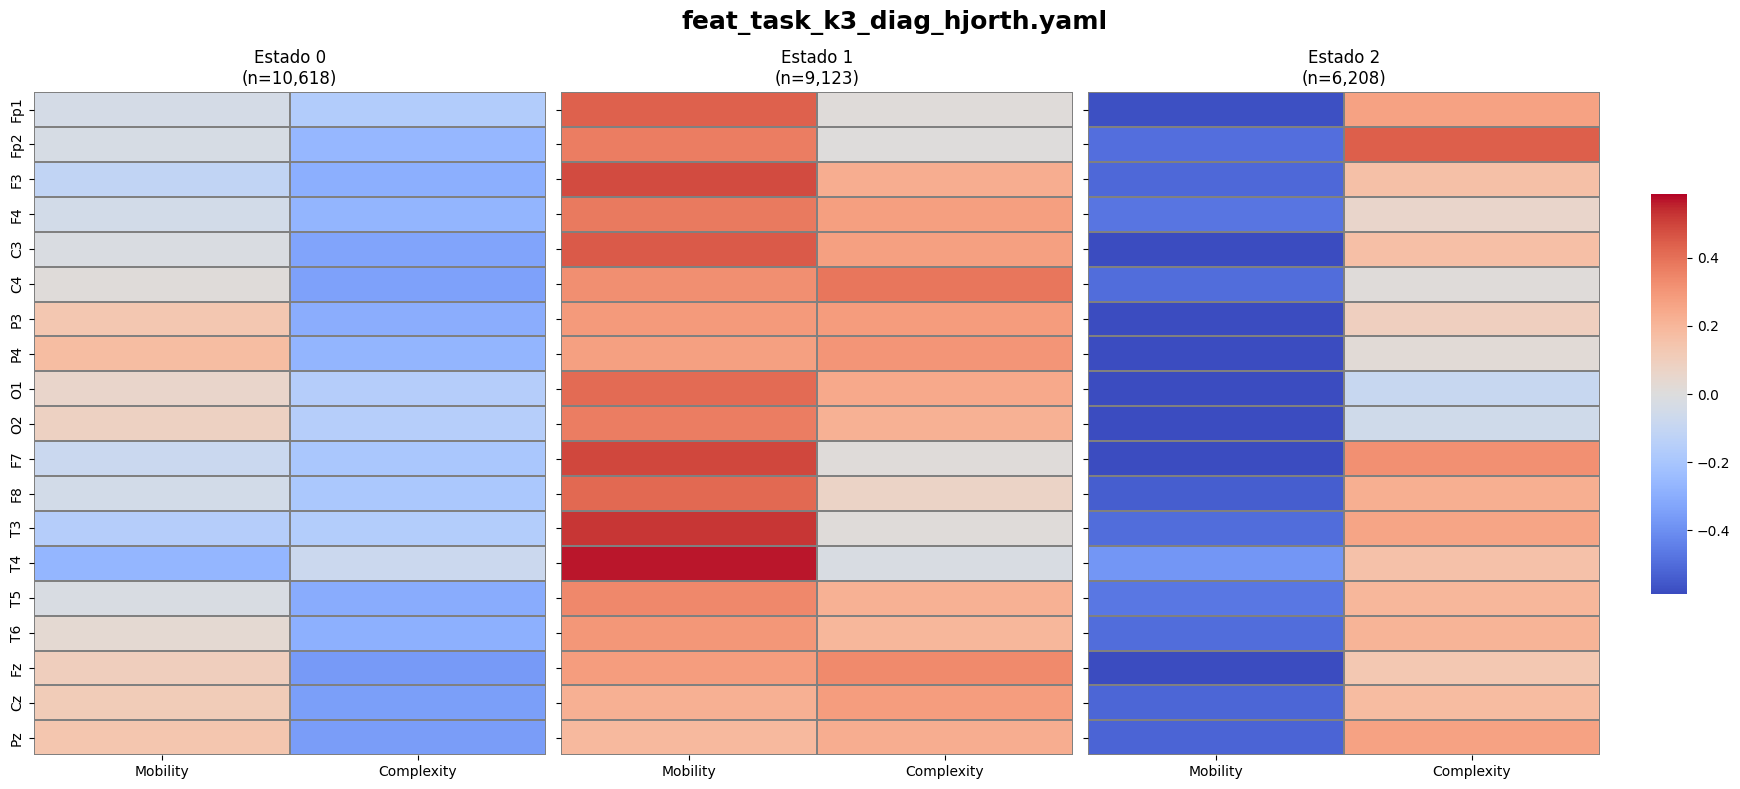

In [4]:
# ============================================================
# BLOQUE 4 — STATE PROFILES
# ============================================================

feature_flags = cfg['features']

metrics = []

if feature_flags['use_theta']:
    metrics.append('Theta')

if feature_flags['use_alpha']:
    metrics.append('Alpha')

if feature_flags['use_beta']:
    metrics.append('Beta')

if feature_flags['use_hjorth']:
    metrics.extend(['Mobility', 'Complexity'])

if feature_flags['use_entropy']:
    metrics.append('Entropy')

print(metrics)

# ------------------------------------------------------------
# CHANNELS
# ------------------------------------------------------------

ch_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

# ------------------------------------------------------------
# STATE PROFILES
# ------------------------------------------------------------

state_profiles = []

for s in range(n_states):

    idx = (viterbi_paths == s)

    mean_profile = np.mean(
        X_scaled[idx],
        axis=0
    )

    state_profiles.append(mean_profile)

state_profiles = np.array(state_profiles)

print(state_profiles.shape)

# ------------------------------------------------------------
# RESHAPE
# ------------------------------------------------------------

n_channels = len(ch_names)

state_profiles_3d = np.zeros(
    (
        n_states,
        n_channels,
        len(metrics)
    )
)

for m_idx in range(len(metrics)):

    start = m_idx * n_channels
    end = (m_idx + 1) * n_channels

    state_profiles_3d[:, :, m_idx] = (
        state_profiles[:, start:end]
    )

# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

global_absmax = np.percentile(
    np.abs(state_profiles_3d),
    95
)

fig, axes = plt.subplots(
    1,
    n_states,
    figsize=(6 * n_states, 8),
    sharey=True
)

if n_states == 1:
    axes = [axes]

cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])

for s in range(n_states):

    ax = axes[s]

    sns.heatmap(
        state_profiles_3d[s],
        cmap='coolwarm',
        center=0,
        vmin=-global_absmax,
        vmax=global_absmax,
        xticklabels=metrics,
        yticklabels=ch_names,
        linewidths=0.3,
        linecolor='gray',
        ax=ax,
        cbar=(s == 0),
        cbar_ax=None if s > 0 else cbar_ax
    )

    n_windows = np.sum(viterbi_paths == s)

    ax.set_title(
        f"Estado {s}\n(n={n_windows:,})"
    )

plt.suptitle(
    f"{exp_name}",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 0.9, 1])

plt.show()

COSINE SIMILARITY MATRIX
[[ 1.     -0.4949 -0.2812]
 [-0.4949  1.     -0.6947]
 [-0.2812 -0.6947  1.    ]]


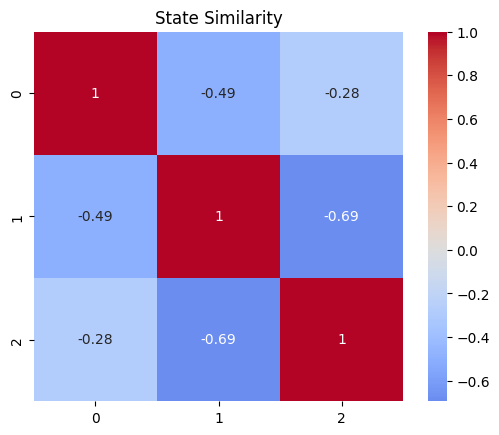

In [5]:
# ============================================================
# BLOQUE 5 — COSINE SIMILARITY
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
    state_profiles
)

print("=" * 60)
print("COSINE SIMILARITY MATRIX")
print("=" * 60)

print(
    np.round(similarity_matrix, 4)
)

sns.heatmap(
    similarity_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True
)

plt.title("State Similarity")

plt.show()

In [6]:
# ============================================================
# BLOQUE 6 — DWELL TIMES
# ============================================================

STEP_SIZE_MS = 100

print("=" * 60)
print("DWELL TIMES")
print("=" * 60)

for s in range(n_states):

    runs = []

    current_run = 0

    for val in viterbi_paths:

        if val == s:
            current_run += 1

        else:
            if current_run > 0:
                runs.append(current_run)

            current_run = 0

    if current_run > 0:
        runs.append(current_run)

    dwell_ms = np.mean(runs) * STEP_SIZE_MS

    print(
        f"State {s}: "
        f"{dwell_ms:.2f} ms"
    )

DWELL TIMES
State 0: 883.36 ms
State 1: 1070.77 ms
State 2: 578.56 ms


RAÍZ DETECTADA: c:\Proyectos\eeg_hmm_project
CARGANDO:       feat_task_k3_diag_hjorth.yaml
HMM PATH:       c:\Proyectos\eeg_hmm_project\outputs\processed\experiments\feature_hmm\task\feat_task_k3_diag_hjorth.yaml
FEATURES PATH:  c:\Proyectos\eeg_hmm_project\data\interim\features\task_hjorthonly_temporalqc

✅ Estados HMM detectados: 3
✅ Sujetos cargados: 118
✅ Ventanas ERP esperadas: 11

Reconstruyendo secuencias ERP...

Distribución de longitudes detectadas:
[(np.int64(11), 2359)]

TIME AXIS CORREGIDO
Inicio: -350.0 ms
Final:  650.0 ms

Matrices ERP finales:
GO                   -> (1179, 11)
NOGO                 -> (1180, 11)
ADULTO_GO            -> (599, 11)
ADULTO_NOGO          -> (600, 11)
ADOLESCENTE_GO       -> (580, 11)
ADOLESCENTE_NOGO     -> (580, 11)


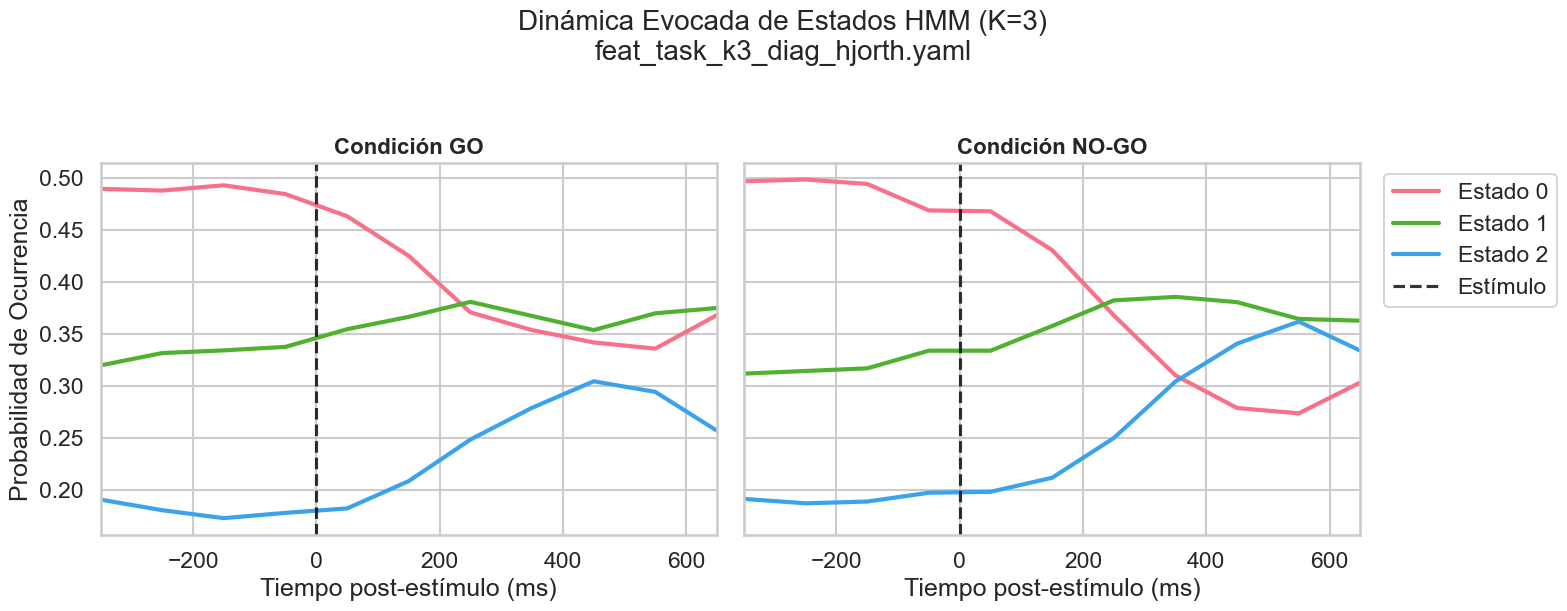

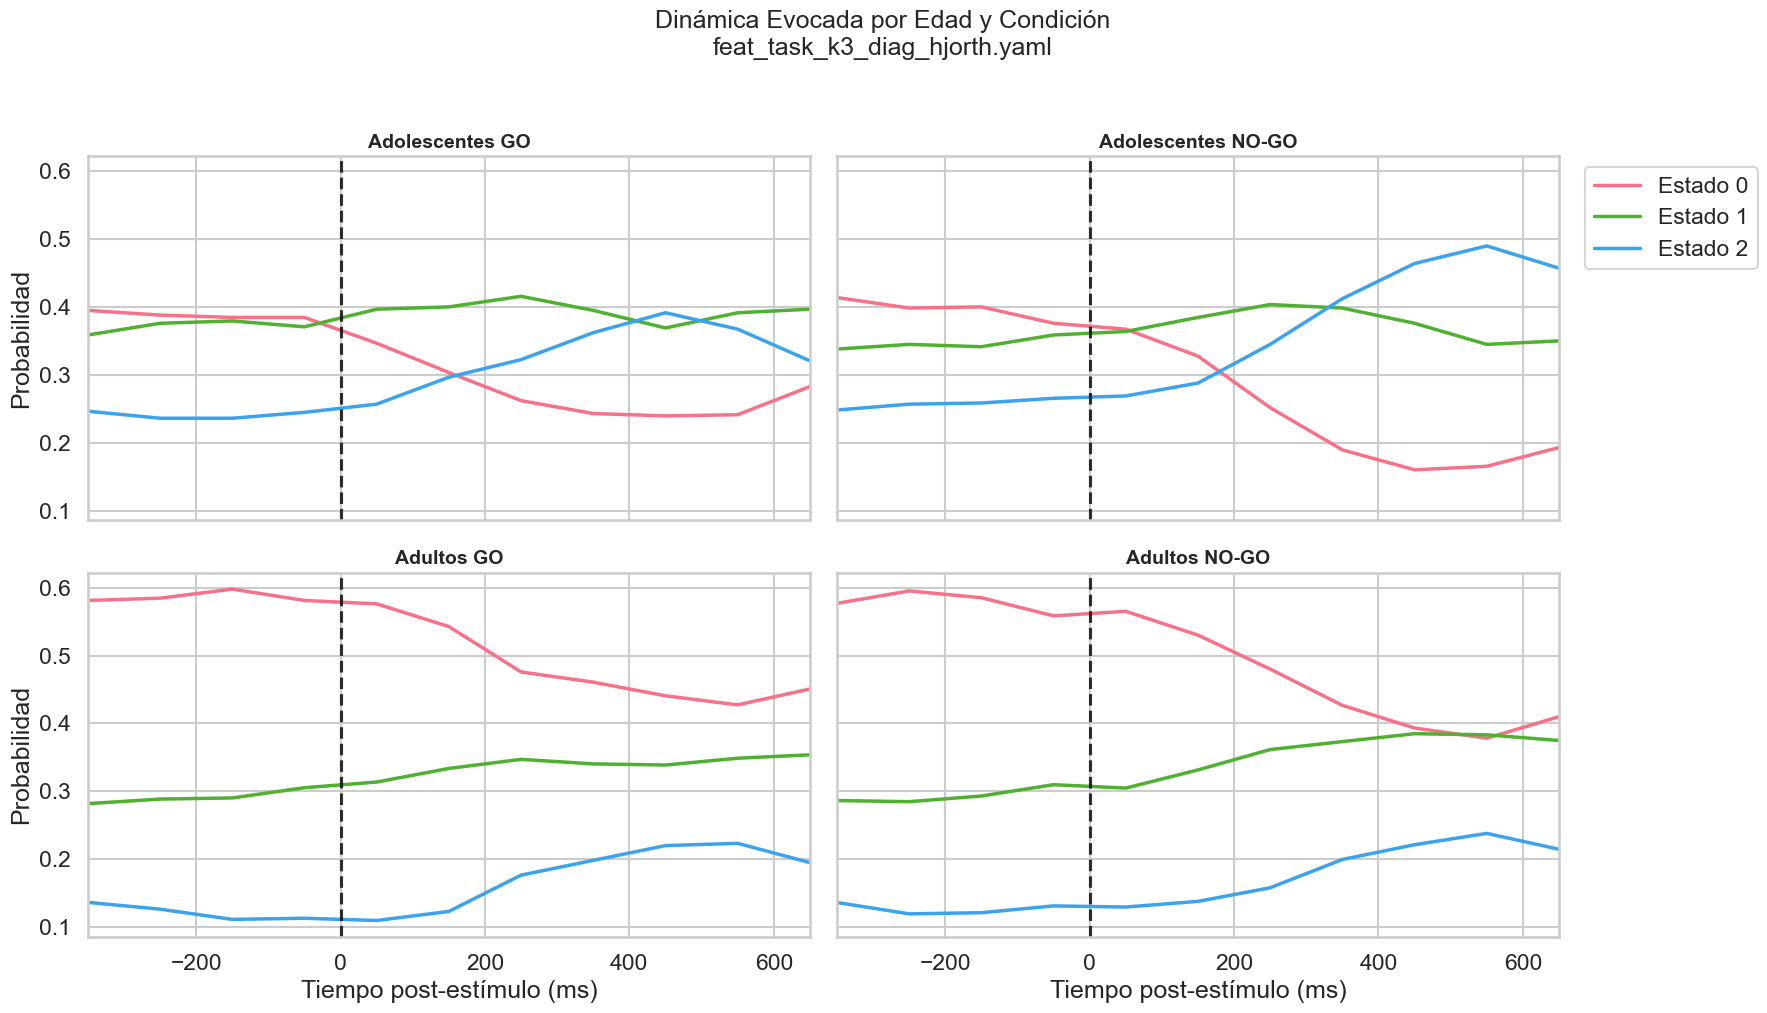


PEAK EVOKED PROBABILITIES


,Group,State,Peak Time (ms),Peak Probability
0,GO,0,-150.0,0.492791
1,GO,1,250.0,0.380831
2,GO,2,450.0,0.304495
3,NOGO,0,-250.0,0.498305
4,NOGO,1,350.0,0.385593
5,NOGO,2,550.0,0.361864
6,ADULTO_GO,0,-150.0,0.597663
7,ADULTO_GO,1,650.0,0.353923
8,ADULTO_GO,2,550.0,0.223706
9,ADULTO_NOGO,0,-250.0,0.595000


In [8]:
# ============================================================
# EVOKED STATE DYNAMICS (GO vs NO-GO) - K=4
# VERSIÓN CORREGIDA ERP-HMM
# ============================================================

import os
import sys
import yaml
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display

# ============================================================
# 1. LOCALIZACIÓN INTELIGENTE DE LA RAÍZ DEL PROYECTO
# ============================================================

project_root = os.getcwd()

while not os.path.exists(os.path.join(project_root, 'configs')) \
      and project_root != os.path.dirname(project_root):
    project_root = os.path.dirname(project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

def clean_path(yaml_path, root):
    limpio = yaml_path.replace('../../', '').replace('../', '')
    return os.path.normpath(os.path.join(root, limpio))

# ============================================================
# 2. CARGA DEL EXPERIMENTO
# ============================================================

SUBFOLDER = 'depured_methology_experiments'
YAML_NAME = 'feat_task_k3_diag_hjorth.yaml'

CONFIG_PATH = os.path.join(
    project_root,
    'configs',
    'experiments',
    SUBFOLDER,
    YAML_NAME
)

if not os.path.exists(CONFIG_PATH):
    CONFIG_PATH = os.path.join(
        project_root,
        'configs',
        'experiments',
        YAML_NAME
    )

if not os.path.exists(CONFIG_PATH):
    raise FileNotFoundError(
        f"❌ ERROR: No se halló el YAML.\n{CONFIG_PATH}"
    )

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

exp_name = cfg['experiment']['name']

n_states = cfg['pipeline']['hmm']['k_states']

out_dir_base = clean_path(
    cfg['paths']['output_dir'],
    project_root
)

exp_dir = os.path.join(out_dir_base, exp_name)

features_dir = clean_path(
    cfg['paths']['features_dir'],
    project_root
)

print("=" * 60)
print(f"RAÍZ DETECTADA: {project_root}")
print(f"CARGANDO:       {exp_name}")
print(f"HMM PATH:       {exp_dir}")
print(f"FEATURES PATH:  {features_dir}")
print("=" * 60)

# ============================================================
# 3. CARGA DE DATOS
# ============================================================

viterbi = np.load(
    os.path.join(
        exp_dir,
        f'viterbi_paths_k{n_states}.npy'
    )
)

length_files = sorted(
    glob.glob(
        os.path.join(features_dir, '*_lengths.npy')
    )
)

# ============================================================
# 4. PARÁMETROS ERP
# ============================================================

EPOCH_START_MS = -500
EPOCH_END_MS   = 800

WINDOW_SIZE_MS = 300
STEP_SIZE_MS   = 100

# ============================================================
# CÁLCULO CORRECTO DE VENTANAS ERP
# ============================================================

WINDOWS_PER_EPOCH = int(
    (
        (EPOCH_END_MS - EPOCH_START_MS)
        - WINDOW_SIZE_MS
    ) / STEP_SIZE_MS
) + 1

print(f"\n✅ Estados HMM detectados: {n_states}")
print(f"✅ Sujetos cargados: {len(length_files)}")
print(f"✅ Ventanas ERP esperadas: {WINDOWS_PER_EPOCH}")

# ============================================================
# 5. LISTA DE ADULTOS
# ============================================================

LISTA_ADULTOS = [
    'AAELSC', 'AAGFSC', 'EDGSSIN', 'FIJRBSIN', 'GSASC',
    'IJALSC', 'JAGSSC', 'LHACSIN', 'MAEGLSC', 'MAHLSC',
    'MFGSIN', 'MGOKSC', 'RAMPSIN', 'SDBGSIN', 'VMRSIN',
    'AVLLSC', 'BMPSC', 'CGMSIN', 'CJGSIN', 'CPGSC',
    'CPMHSIN', 'GGMSIN', 'IABWSC', 'JAUSIN', 'JGCSC',
    'MGVGSC', 'RKACSC', 'SEOOSIN', 'TTOSC', 'VBPSIN'
]

# ============================================================
# 6. HELPERS
# ============================================================

def parse_subject_info(filename):

    clean_name = filename.upper()

    clean_name = (
        clean_name
        .replace('_SIN_CONTEXTO', '')
        .replace('_EPO', '')
        .replace('_LENGTHS.NPY', '')
        .replace('.NPY', '')
    )

    if clean_name.endswith("NOGO") or clean_name.endswith("NG"):
        condicion = "NOGO"

        subject_id_real = (
            clean_name
            .replace("NOGO", "")
            .replace("NG", "")
        )

    elif clean_name.endswith("GO"):

        condicion = "GO"

        subject_id_real = clean_name[:-2]

    else:

        condicion = "GO"
        subject_id_real = clean_name

    grupo = (
        "ADULTO"
        if any(
            subject_id_real.startswith(adulto)
            for adulto in LISTA_ADULTOS
        )
        else "ADOLESCENTE"
    )

    return subject_id_real, grupo, condicion

def calcular_probabilidades(
    matriz,
    num_estados,
    n_windows
):

    if len(matriz) == 0:
        return np.zeros((num_estados, n_windows))

    probs = np.zeros(
        (num_estados, matriz.shape[1])
    )

    for s in range(num_estados):

        probs[s] = np.mean(
            matriz == s,
            axis=0
        )

    return probs

# ============================================================
# 7. RECONSTRUCCIÓN ERP CORREGIDA
# ============================================================

print("\nReconstruyendo secuencias ERP...")

secuencias_crudas = {
    "GO": [],
    "NOGO": [],
    "ADULTO_GO": [],
    "ADULTO_NOGO": [],
    "ADOLESCENTE_GO": [],
    "ADOLESCENTE_NOGO": []
}

start_idx = 0

longitudes_detectadas = []

for f_path in length_files:

    filename = os.path.basename(f_path)

    subject_id_real, grupo, condicion = parse_subject_info(
        filename
    )

    lengths = np.load(f_path)

    for ep_len in lengths:

        ep_path = viterbi[
            start_idx:start_idx + ep_len
        ]

        start_idx += ep_len

        longitudes_detectadas.append(ep_len)

        # ====================================================
        # FILTRO CRÍTICO ERP
        # ====================================================

        if ep_len != WINDOWS_PER_EPOCH:
            continue

        secuencias_crudas[condicion].append(
            ep_path
        )

        secuencias_crudas[
            f"{grupo}_{condicion}"
        ].append(ep_path)

# ============================================================
# DEBUG DE LONGITUDES
# ============================================================

print("\nDistribución de longitudes detectadas:")
print(
    Counter(longitudes_detectadas)
    .most_common(15)
)

# ============================================================
# 8. MATRICES LIMPIAS
# ============================================================

matrices = {}

for cond_key, cond_val in secuencias_crudas.items():

    if len(cond_val) == 0:
        continue

    matrices[cond_key] = np.array(cond_val)

# ============================================================
# 9. PROBABILIDADES EVOCADAS
# ============================================================

probs = {}

for cond_key, cond_val in matrices.items():

    probs[cond_key] = calcular_probabilidades(
        cond_val,
        n_states,
        WINDOWS_PER_EPOCH
    )

# ============================================================
# 10. EJE TEMPORAL CORRECTO
# ============================================================

time_axis = (
    np.arange(WINDOWS_PER_EPOCH)
    * STEP_SIZE_MS
) + EPOCH_START_MS + (WINDOW_SIZE_MS / 2)

print("\n" + "=" * 60)
print("TIME AXIS CORREGIDO")
print(f"Inicio: {time_axis[0]} ms")
print(f"Final:  {time_axis[-1]} ms")
print("=" * 60)

# ============================================================
# SANITY CHECK
# ============================================================

print("\nMatrices ERP finales:")

for cond_key, cond_val in matrices.items():
    print(f"{cond_key:<20} -> {cond_val.shape}")

# ============================================================
# 11. VISUALIZACIÓN GLOBAL
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="talk"
)

colors = sns.color_palette(
    "husl",
    n_states
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharey=True,
    sharex=True
)

paneles = [
    ("GO", "Condición GO"),
    ("NOGO", "Condición NO-GO")
]

for ax, (cond, title) in zip(axes, paneles):

    if cond in probs:

        matriz = probs[cond]

        for s in range(n_states):

            ax.plot(
                time_axis,
                matriz[s],
                lw=3,
                label=f"Estado {s}",
                color=colors[s]
            )

    ax.set_title(
        title,
        fontsize=16,
        fontweight='bold'
    )

    ax.set_xlabel(
        "Tiempo post-estímulo (ms)"
    )

    if cond == "GO":
        ax.set_ylabel(
            "Probabilidad de Ocurrencia"
        )

    ax.axvline(
        x=0,
        linestyle='--',
        alpha=0.8,
        color='black',
        label='Estímulo'
    )

    ax.set_xlim(
        time_axis.min(),
        time_axis.max()
    )

axes[1].legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.suptitle(
    f"Dinámica Evocada de Estados HMM (K={n_states})\n{exp_name}",
    fontsize=20,
    y=1.03
)

plt.tight_layout()
plt.show()

# ============================================================
# 12. VISUALIZACIÓN CLÍNICA
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 10),
    sharex=True,
    sharey=True
)

config_panels = [
    (0, 0, "ADOLESCENTE_GO", "Adolescentes GO"),
    (0, 1, "ADOLESCENTE_NOGO", "Adolescentes NO-GO"),
    (1, 0, "ADULTO_GO", "Adultos GO"),
    (1, 1, "ADULTO_NOGO", "Adultos NO-GO")
]

for row, col, cond, title in config_panels:

    ax = axes[row, col]

    if cond in probs:

        matriz = probs[cond]

        for s in range(n_states):

            ax.plot(
                time_axis,
                matriz[s],
                lw=2.5,
                label=f"Estado {s}",
                color=colors[s]
            )

    ax.set_title(
        title,
        fontsize=14,
        fontweight='bold'
    )

    ax.axvline(
        x=0,
        linestyle='--',
        alpha=0.8,
        color='black'
    )

    if row == 1:
        ax.set_xlabel(
            "Tiempo post-estímulo (ms)"
        )

    if col == 0:
        ax.set_ylabel(
            "Probabilidad"
        )

    ax.set_xlim(
        time_axis.min(),
        time_axis.max()
    )

axes[0,1].legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.suptitle(
    f"Dinámica Evocada por Edad y Condición\n{exp_name}",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

# ============================================================
# 13. TABLA DE PEAKS
# ============================================================

print("\n" + "=" * 60)
print("PEAK EVOKED PROBABILITIES")
print("=" * 60)

summary = []

for group_name, matrix in probs.items():

    if matrix.shape[1] == 0:
        continue

    for s in range(n_states):

        peak_idx = np.argmax(matrix[s])

        summary.append({
            'Group': group_name,
            'State': s,
            'Peak Time (ms)': time_axis[peak_idx],
            'Peak Probability': matrix[s, peak_idx]
        })

df_summary = pd.DataFrame(summary)

display(df_summary)

In [9]:
# ============================================================
# BLOQUE 3 — TRANSITION MATRIX
# ============================================================

transmat = model.transmat_

df_trans = pd.DataFrame(
    np.round(transmat, 3),
    columns=[f"To S{i}" for i in range(n_states)],
    index=[f"From S{i}" for i in range(n_states)]
)

print("=" * 60)
print("TRANSITION MATRIX")
print("=" * 60)

display(df_trans)

# ------------------------------------------------------------
# SELF TRANSITIONS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STATE PERSISTENCE")
print("=" * 60)

for s in range(n_states):

    occupancy = np.mean(viterbi_paths == s)

    persistence = transmat[s, s]

    count = np.sum(viterbi_paths == s)

    print(f"\nState {s}")
    print("-" * 20)

    print(f"Fractional Occupancy : {occupancy:.4f}")
    print(f"Total Windows        : {count:,}")
    print(f"Self-transition      : {persistence:.4f}")

TRANSITION MATRIX


,To S0,To S1,To S2
From S0,0.881,0.053,0.066
From S1,0.032,0.920,0.048
From S2,0.094,0.052,0.855



STATE PERSISTENCE

State 0
--------------------
Fractional Occupancy : 0.4092
Total Windows        : 10,618
Self-transition      : 0.8812

State 1
--------------------
Fractional Occupancy : 0.3516
Total Windows        : 9,123
Self-transition      : 0.9199

State 2
--------------------
Fractional Occupancy : 0.2392
Total Windows        : 6,208
Self-transition      : 0.8546
